In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DB_PATH = r"C:\Users\ASUS ROG\last-mile-delivery-intelligence\data\supply_chain.db"

import sqlite3
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM shipments", conn)
conn.close()

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nTarget variable distribution:")
print(df['on_time'].value_counts())
print(f"\nOn-time rate: {df['on_time'].mean()*100:.2f}%")
print(f"\nMissing values:")
print(df.isnull().sum())
df.head()

Shape: (10999, 12)

Columns: ['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms', 'on_time']

Target variable distribution:
on_time
1    6563
0    4436
Name: count, dtype: int64

On-time rate: 59.67%

Missing values:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
on_time                0
dtype: int64


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


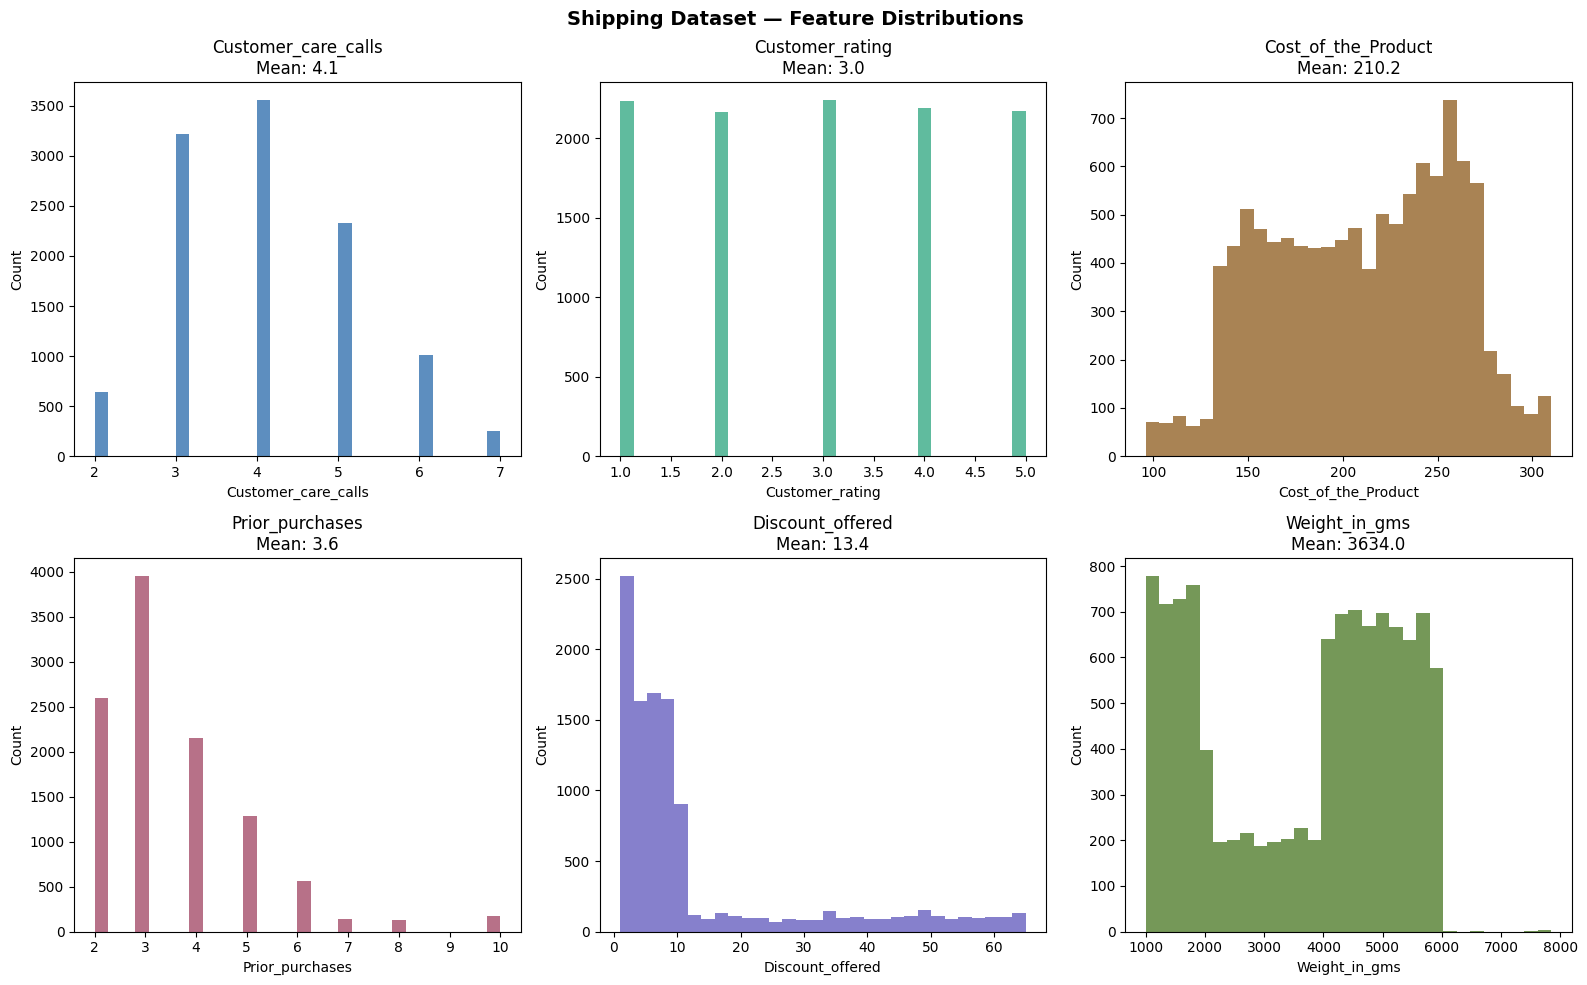

In [2]:
# ── Understand distributions ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Shipping Dataset — Feature Distributions',
             fontsize=14, fontweight='bold')

# Plot distributions of key numeric columns
numeric_cols = ['Customer_care_calls', 'Customer_rating',
                'Cost_of_the_Product', 'Prior_purchases',
                'Discount_offered', 'Weight_in_gms']
colors = ['#185FA5','#1D9E75','#854F0B','#993556','#534AB7','#3B6D11']

for i, (col, color) in enumerate(zip(numeric_cols, colors)):
    row, c = i//3, i%3
    axes[row][c].hist(df[col], bins=30, color=color, alpha=0.7)
    axes[row][c].set_title(f'{col}\nMean: {df[col].mean():.1f}')
    axes[row][c].set_xlabel(col)
    axes[row][c].set_ylabel('Count')

plt.tight_layout()
plt.savefig(r'C:\Users\ASUS ROG\last-mile-delivery-intelligence\data\processed\chart6_feature_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# ── Feature Engineering ───────────────────────
df_feat = df.copy()  # Always work on a copy, never the original

# FEATURE 1: High customer care calls flag
# Business logic: 4+ calls = very frustrated customer = likely problem order
df_feat['high_care_calls'] = (df_feat['Customer_care_calls'] >= 4).astype(int)
print(f"high_care_calls: {df_feat['high_care_calls'].value_counts().to_dict()}")

# FEATURE 2: Discount tier
# Business logic: Heavily discounted items may be lower priority for fulfillment
df_feat['discount_tier'] = pd.cut(
    df_feat['Discount_offered'],
    bins=[-1, 0, 10, 30, 100],
    labels=['none', 'low', 'medium', 'high']
)

# FEATURE 3: Weight category
# Business logic: Heavier items take longer and cost more to ship
df_feat['weight_kg'] = df_feat['Weight_in_gms'] / 1000
df_feat['weight_category'] = pd.cut(
    df_feat['weight_kg'],
    bins=[0, 1, 3, 6, 100],
    labels=['light', 'medium', 'heavy', 'very_heavy']
)

# FEATURE 4: High value product flag
# Business logic: Premium products may get different handling
median_price = df_feat['Cost_of_the_Product'].median()
df_feat['is_high_value'] = (
    df_feat['Cost_of_the_Product'] > median_price
).astype(int)
print(f"Median price: {median_price:.2f}")

# FEATURE 5: Repeat customer flag
# Business logic: Experienced customers may navigate delays better
df_feat['is_repeat_customer'] = (
    df_feat['Prior_purchases'] >= 3
).astype(int)

# FEATURE 6: Low satisfaction flag
# Business logic: Already-unhappy customers are at higher churn risk
df_feat['low_satisfaction'] = (
    df_feat['Customer_rating'] <= 2
).astype(int)

print(f"\nFeature engineering complete!")
print(f"Original columns: {len(df.columns)}")
print(f"New columns: {len(df_feat.columns)}")
print(f"\nNew features added:")
new_feats = ['high_care_calls','discount_tier','weight_kg',
             'weight_category','is_high_value','is_repeat_customer',
             'low_satisfaction']
for f in new_feats:
    print(f"  {f}")

high_care_calls: {1: 7144, 0: 3855}
Median price: 214.00

Feature engineering complete!
Original columns: 12
New columns: 19

New features added:
  high_care_calls
  discount_tier
  weight_kg
  weight_category
  is_high_value
  is_repeat_customer
  low_satisfaction


In [4]:
from sklearn.preprocessing import LabelEncoder

df_final = df_feat.copy()

# Encode all categorical columns to numbers
# ML models cannot process text — everything must be numeric
cat_cols = ['Warehouse_block', 'Mode_of_Shipment',
            'Product_importance', 'Gender',
            'discount_tier', 'weight_category']

le = LabelEncoder()
for col in cat_cols:
    df_final[col] = le.fit_transform(df_final[col].astype(str))
    print(f"Encoded '{col}': {df_final[col].unique()}")

# Drop weight_kg (we have weight_category already)
df_final = df_final.drop(columns=['weight_kg'])

# Verify target column exists
print(f"\nTarget column 'on_time' present: {'on_time' in df_final.columns}")
print(f"Target distribution:\n{df_final['on_time'].value_counts()}")

# Save to processed folder
PROCESSED = r"C:\Users\ASUS ROG\last-mile-delivery-intelligence\data\processed"
df_final.to_csv(f"{PROCESSED}\\features_ready.csv", index=False)
print(f"\nSaved: features_ready.csv")
print(f"Shape: {df_final.shape}")
print(f"Columns: {list(df_final.columns)}")

Encoded 'Warehouse_block': [3 4 0 1 2]
Encoded 'Mode_of_Shipment': [0 2 1]
Encoded 'Product_importance': [1 2 0]
Encoded 'Gender': [0 1]
Encoded 'discount_tier': [0 1 2]
Encoded 'weight_category': [1 0 2]

Target column 'on_time' present: True
Target distribution:
on_time
1    6563
0    4436
Name: count, dtype: int64

Saved: features_ready.csv
Shape: (10999, 18)
Columns: ['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms', 'on_time', 'high_care_calls', 'discount_tier', 'weight_category', 'is_high_value', 'is_repeat_customer', 'low_satisfaction']
